In [14]:

"""
Ablation Study: Systematic Agent Combination Analysis

Tests 7 configurations on TEST SET (final held-out evaluation):
1. Agent 1 only (Labs)
2. Agent 2 only (Notes)  
3. Agent 3 only (Vitals)
4. Agent 1 + Agent 2 (simple averaging)
5. Agent 1 + Agent 3 (simple averaging)
6. Agent 2 + Agent 3 (simple averaging)
7. All 3 agents (Learned Fusion)

Goal: Prove that learned fusion > individual agents > simple averaging
"""

import sys
sys.path.append('../../')

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import xgboost as xgb
from sklearn.model_selection import train_test_split

# Communication protocol
from src.communication.protocol import DISEASE_LIST

# Plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ Imports complete")
print(f"\nTesting {len(DISEASE_LIST)} diseases across 7 configurations")
print(f"Evaluation: TEST SET (30% held-out, never seen during training)")

✅ Imports complete

Testing 9 diseases across 7 configurations
Evaluation: TEST SET (30% held-out, never seen during training)


In [15]:

print("="*70)
print("📂 LOADING DATA AND CREATING SPLITS")
print("="*70)

# Load fusion matrix
X_fusion = np.load('../../data/processed/X_fusion_val.npy')
print(f"\n✅ Fusion features: {X_fusion.shape}")

# Extract agent predictions
agent1_pred = X_fusion[:, 0:9]    # Agent 1 (Labs)
agent2_pred = X_fusion[:, 9:18]   # Agent 2 (Notes)
agent3_pred = X_fusion[:, 18:27]  # Agent 3 (Vitals)

print(f"\nAgent predictions extracted:")
print(f"  Agent 1 (Labs):   {agent1_pred.shape}")
print(f"  Agent 2 (Notes):  {agent2_pred.shape}")
print(f"  Agent 3 (Vitals): {agent3_pred.shape}")

# Load true labels
y_true = {}
for disease in DISEASE_LIST:
    disease_filename = disease.lower()
    y_true[disease] = np.load(f'../../data/processed/y_fusion_val_{disease_filename}.npy')

print(f"\n✅ Labels loaded for {len(DISEASE_LIST)} diseases")
print(f"   Total samples: {len(y_true[DISEASE_LIST[0]])}")

# Create EXACT same split as original fusion training
n_samples = len(X_fusion)
indices = np.arange(n_samples)

# First split: 70% train+val, 30% test  
train_val_idx, test_idx = train_test_split(
    indices, 
    test_size=0.30, 
    random_state=42
)

# Second split: 50% train, 20% val (from the 70%)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.20/(0.50+0.20),  # 20/70 ≈ 0.286
    random_state=42
)

print(f"\n📊 Data splits (matching original fusion):")
print(f"  Train: {len(train_idx):,} samples ({len(train_idx)/n_samples*100:.1f}%)")
print(f"  Val:   {len(val_idx):,} samples ({len(val_idx)/n_samples*100:.1f}%)")
print(f"  Test:  {len(test_idx):,} samples ({len(test_idx)/n_samples*100:.1f}%)")

print(f"\n🎯 Using TEST SET for final ablation evaluation")
print(f"   (This is held-out data, never used for training or threshold optimization)")

📂 LOADING DATA AND CREATING SPLITS

✅ Fusion features: (4643, 33)

Agent predictions extracted:
  Agent 1 (Labs):   (4643, 9)
  Agent 2 (Notes):  (4643, 9)
  Agent 3 (Vitals): (4643, 9)

✅ Labels loaded for 9 diseases
   Total samples: 4643

📊 Data splits (matching original fusion):
  Train: 2,321 samples (50.0%)
  Val:   929 samples (20.0%)
  Test:  1,393 samples (30.0%)

🎯 Using TEST SET for final ablation evaluation
   (This is held-out data, never used for training or threshold optimization)


In [16]:

print("\n" + "="*70)
print("🔬 CONFIGURATIONS 1-3: INDIVIDUAL AGENTS (TEST SET)")
print("="*70)

individual_results = {
    'Agent 1 (Labs)': [],
    'Agent 2 (Notes)': [],
    'Agent 3 (Vitals)': []
}

agent_predictions = {
    'Agent 1 (Labs)': agent1_pred,
    'Agent 2 (Notes)': agent2_pred,
    'Agent 3 (Vitals)': agent3_pred
}

for agent_name, agent_pred_full in agent_predictions.items():
    print(f"\n{agent_name}:")
    
    for i, disease in enumerate(DISEASE_LIST):
        y_test = y_true[disease][test_idx]
        pred_test = agent_pred_full[test_idx, i]
        
        auc = roc_auc_score(y_test, pred_test)
        f1 = f1_score(y_test, pred_test >= 0.5)
        precision = precision_score(y_test, pred_test >= 0.5, zero_division=0)
        recall = recall_score(y_test, pred_test >= 0.5, zero_division=0)
        
        individual_results[agent_name].append({
            'Disease': disease,
            'AUC': auc,
            'F1': f1,
            'Precision': precision,
            'Recall': recall
        })
        
        print(f"  {disease:30s} AUC: {auc:.3f}, F1: {f1:.3f}")
    
    # Average
    df = pd.DataFrame(individual_results[agent_name])
    print(f"\n  📊 Average - AUC: {df['AUC'].mean():.3f}, F1: {df['F1'].mean():.3f}")


🔬 CONFIGURATIONS 1-3: INDIVIDUAL AGENTS (TEST SET)

Agent 1 (Labs):
  SEPSIS                         AUC: 0.865, F1: 0.533
  PNEUMONIA                      AUC: 0.785, F1: 0.354
  RESPIRATORY_FAILURE            AUC: 0.856, F1: 0.678
  ACUTE_KIDNEY_INJURY            AUC: 0.925, F1: 0.818
  HEART_FAILURE                  AUC: 0.817, F1: 0.608
  ATRIAL_FIBRILLATION            AUC: 0.799, F1: 0.577
  CORONARY_ARTERY_DISEASE        AUC: 0.856, F1: 0.702
  ANEMIA                         AUC: 0.811, F1: 0.598
  PANCREATITIS                   AUC: 0.760, F1: 0.157

  📊 Average - AUC: 0.830, F1: 0.559

Agent 2 (Notes):
  SEPSIS                         AUC: 0.767, F1: 0.398
  PNEUMONIA                      AUC: 0.728, F1: 0.388
  RESPIRATORY_FAILURE            AUC: 0.742, F1: 0.511
  ACUTE_KIDNEY_INJURY            AUC: 0.725, F1: 0.562
  HEART_FAILURE                  AUC: 0.809, F1: 0.632
  ATRIAL_FIBRILLATION            AUC: 0.832, F1: 0.650
  CORONARY_ARTERY_DISEASE        AUC: 0.881, F1: 0.

In [17]:

print("\n" + "="*70)
print("📊 BASELINE: SIMPLE AVERAGING (All 3 Agents, No Learning)")
print("="*70)

def simple_average_fusion(agent_preds_list):
    """Simple averaging - just mean of agent predictions"""
    return np.mean(agent_preds_list, axis=0)

baseline_results = []

for i, disease in enumerate(DISEASE_LIST):
    y_test = y_true[disease][test_idx]
    
    # Average all 3 agents
    avg_pred = simple_average_fusion([
        agent1_pred[test_idx, i],
        agent2_pred[test_idx, i],
        agent3_pred[test_idx, i]
    ])
    
    auc = roc_auc_score(y_test, avg_pred)
    f1 = f1_score(y_test, avg_pred >= 0.5)
    precision = precision_score(y_test, avg_pred >= 0.5, zero_division=0)
    recall = recall_score(y_test, avg_pred >= 0.5, zero_division=0)
    
    baseline_results.append({
        'Disease': disease,
        'AUC': auc,
        'F1': f1,
        'Precision': precision,
        'Recall': recall
    })
    
    print(f"{disease:30s} AUC: {auc:.3f}, F1: {f1:.3f}")

baseline_df = pd.DataFrame(baseline_results)
print(f"\n📊 Baseline (Simple Averaging) Average:")
print(f"   AUC:       {baseline_df['AUC'].mean():.3f}")
print(f"   F1:        {baseline_df['F1'].mean():.3f}")
print(f"   Precision: {baseline_df['Precision'].mean():.3f}")
print(f"   Recall:    {baseline_df['Recall'].mean():.3f}")


📊 BASELINE: SIMPLE AVERAGING (All 3 Agents, No Learning)
SEPSIS                         AUC: 0.900, F1: 0.424
PNEUMONIA                      AUC: 0.878, F1: 0.358
RESPIRATORY_FAILURE            AUC: 0.897, F1: 0.705
ACUTE_KIDNEY_INJURY            AUC: 0.920, F1: 0.786
HEART_FAILURE                  AUC: 0.893, F1: 0.699
ATRIAL_FIBRILLATION            AUC: 0.883, F1: 0.690
CORONARY_ARTERY_DISEASE        AUC: 0.908, F1: 0.757
ANEMIA                         AUC: 0.828, F1: 0.500
PANCREATITIS                   AUC: 0.836, F1: 0.097

📊 Baseline (Simple Averaging) Average:
   AUC:       0.883
   F1:        0.557
   Precision: 0.855
   Recall:    0.459


In [5]:
print("\n" + "="*70)
print("🔬 CONFIGURATIONS 4-6: PAIRWISE COMBINATIONS")
print("="*70)

pairwise_results = {
    'Agent 1+2': [],
    'Agent 1+3': [],
    'Agent 2+3': []
}

pairwise_configs = {
    'Agent 1+2': [agent1_pred, agent2_pred],
    'Agent 1+3': [agent1_pred, agent3_pred],
    'Agent 2+3': [agent2_pred, agent3_pred]
}

for config_name, agent_list in pairwise_configs.items():
    print(f"\n{config_name} (Simple Averaging):")
    
    for i, disease in enumerate(DISEASE_LIST):
        y_val = y_true[disease][val_idx]
        
        # Average the two agents
        avg_pred = simple_average_fusion([
            agent_list[0][val_idx, i],
            agent_list[1][val_idx, i]
        ])
        
        auc = roc_auc_score(y_val, avg_pred)
        f1 = f1_score(y_val, avg_pred >= 0.5)
        precision = precision_score(y_val, avg_pred >= 0.5, zero_division=0)
        recall = recall_score(y_val, avg_pred >= 0.5, zero_division=0)
        
        pairwise_results[config_name].append({
            'Disease': disease,
            'AUC': auc,
            'F1': f1,
            'Precision': precision,
            'Recall': recall
        })
        
        print(f"  {disease:30s} AUC: {auc:.3f}, F1: {f1:.3f}")
    
    # Average
    df = pd.DataFrame(pairwise_results[config_name])
    print(f"\n  Average AUC: {df['AUC'].mean():.3f}, F1: {df['F1'].mean():.3f}")


🔬 CONFIGURATIONS 4-6: PAIRWISE COMBINATIONS

Agent 1+2 (Simple Averaging):
  SEPSIS                         AUC: 0.867, F1: 0.391
  PNEUMONIA                      AUC: 0.816, F1: 0.355
  RESPIRATORY_FAILURE            AUC: 0.840, F1: 0.659
  ACUTE_KIDNEY_INJURY            AUC: 0.922, F1: 0.776
  HEART_FAILURE                  AUC: 0.870, F1: 0.705
  ATRIAL_FIBRILLATION            AUC: 0.873, F1: 0.706
  CORONARY_ARTERY_DISEASE        AUC: 0.880, F1: 0.758
  ANEMIA                         AUC: 0.759, F1: 0.384
  PANCREATITIS                   AUC: 0.817, F1: 0.195

  Average AUC: 0.849, F1: 0.548

Agent 1+3 (Simple Averaging):
  SEPSIS                         AUC: 0.888, F1: 0.509
  PNEUMONIA                      AUC: 0.829, F1: 0.379
  RESPIRATORY_FAILURE            AUC: 0.870, F1: 0.715
  ACUTE_KIDNEY_INJURY            AUC: 0.957, F1: 0.843
  HEART_FAILURE                  AUC: 0.884, F1: 0.681
  ATRIAL_FIBRILLATION            AUC: 0.860, F1: 0.628
  CORONARY_ARTERY_DISEASE        AU

In [18]:

print("\n" + "="*70)
print("🔬 CONFIGURATIONS 4-6: PAIRWISE COMBINATIONS (TEST SET)")
print("="*70)

pairwise_results = {
    'Agent 1+2': [],
    'Agent 1+3': [],
    'Agent 2+3': []
}

pairwise_configs = {
    'Agent 1+2': [agent1_pred, agent2_pred],
    'Agent 1+3': [agent1_pred, agent3_pred],
    'Agent 2+3': [agent2_pred, agent3_pred]
}

for config_name, agent_list in pairwise_configs.items():
    print(f"\n{config_name} (Simple Averaging):")
    
    for i, disease in enumerate(DISEASE_LIST):
        y_test = y_true[disease][test_idx]
        
        # Average the two agents
        avg_pred = simple_average_fusion([
            agent_list[0][test_idx, i],
            agent_list[1][test_idx, i]
        ])
        
        auc = roc_auc_score(y_test, avg_pred)
        f1 = f1_score(y_test, avg_pred >= 0.5)
        precision = precision_score(y_test, avg_pred >= 0.5, zero_division=0)
        recall = recall_score(y_test, avg_pred >= 0.5, zero_division=0)
        
        pairwise_results[config_name].append({
            'Disease': disease,
            'AUC': auc,
            'F1': f1,
            'Precision': precision,
            'Recall': recall
        })
        
        print(f"  {disease:30s} AUC: {auc:.3f}, F1: {f1:.3f}")
    
    # Average
    df = pd.DataFrame(pairwise_results[config_name])
    print(f"\n  📊 Average - AUC: {df['AUC'].mean():.3f}, F1: {df['F1'].mean():.3f}")


🔬 CONFIGURATIONS 4-6: PAIRWISE COMBINATIONS (TEST SET)

Agent 1+2 (Simple Averaging):
  SEPSIS                         AUC: 0.879, F1: 0.415
  PNEUMONIA                      AUC: 0.818, F1: 0.331
  RESPIRATORY_FAILURE            AUC: 0.862, F1: 0.667
  ACUTE_KIDNEY_INJURY            AUC: 0.899, F1: 0.777
  HEART_FAILURE                  AUC: 0.859, F1: 0.667
  ATRIAL_FIBRILLATION            AUC: 0.863, F1: 0.681
  CORONARY_ARTERY_DISEASE        AUC: 0.899, F1: 0.761
  ANEMIA                         AUC: 0.801, F1: 0.492
  PANCREATITIS                   AUC: 0.805, F1: 0.254

  📊 Average - AUC: 0.854, F1: 0.561

Agent 1+3 (Simple Averaging):
  SEPSIS                         AUC: 0.878, F1: 0.511
  PNEUMONIA                      AUC: 0.855, F1: 0.405
  RESPIRATORY_FAILURE            AUC: 0.880, F1: 0.713
  ACUTE_KIDNEY_INJURY            AUC: 0.935, F1: 0.824
  HEART_FAILURE                  AUC: 0.870, F1: 0.669
  ATRIAL_FIBRILLATION            AUC: 0.834, F1: 0.584
  CORONARY_ARTERY_DI

In [19]:

print("\n" + "="*70)
print("🔧 CREATING ENHANCED FEATURES FOR FUSION")
print("="*70)

def create_enhanced_features(X_base):
    """
    Create 105 features total:
    - 33 original features
    - 72 engineered features (interactions, ratios, agreements)
    """
    n_samples = X_base.shape[0]
    X_enhanced = np.zeros((n_samples, 105))
    
    # Original 33 features (0-32)
    X_enhanced[:, 0:33] = X_base
    
    # Extract agent predictions
    agent1_preds = X_base[:, 0:9]
    agent2_preds = X_base[:, 9:18]
    agent3_preds = X_base[:, 18:27]
    
    feature_idx = 33
    
    # 1. Pairwise products (9 diseases × 3 pairs = 27 features)
    X_enhanced[:, feature_idx:feature_idx+9] = agent1_preds * agent2_preds
    feature_idx += 9
    X_enhanced[:, feature_idx:feature_idx+9] = agent1_preds * agent3_preds
    feature_idx += 9
    X_enhanced[:, feature_idx:feature_idx+9] = agent2_preds * agent3_preds
    feature_idx += 9
    
    # 2. Pairwise differences (9 diseases × 3 pairs = 27 features)
    X_enhanced[:, feature_idx:feature_idx+9] = np.abs(agent1_preds - agent2_preds)
    feature_idx += 9
    X_enhanced[:, feature_idx:feature_idx+9] = np.abs(agent1_preds - agent3_preds)
    feature_idx += 9
    X_enhanced[:, feature_idx:feature_idx+9] = np.abs(agent2_preds - agent3_preds)
    feature_idx += 9
    
    # 3. Agreement indicators (9 diseases)
    agreement = ((agent1_preds > 0.5) == (agent2_preds > 0.5)) & \
                ((agent2_preds > 0.5) == (agent3_preds > 0.5))
    X_enhanced[:, feature_idx:feature_idx+9] = agreement.astype(float)
    feature_idx += 9
    
    # 4. Variance across agents (9 diseases)
    all_preds = np.stack([agent1_preds, agent2_preds, agent3_preds], axis=0)
    variance = np.var(all_preds, axis=0)
    X_enhanced[:, feature_idx:feature_idx+9] = variance
    feature_idx += 9
    
    assert feature_idx == 105, f"Expected 105 features, got {feature_idx}"
    
    return X_enhanced

# Create enhanced features for test set
X_fusion_enhanced = create_enhanced_features(X_fusion)
X_test_enhanced = X_fusion_enhanced[test_idx]

print(f"\n✅ Enhanced features created: {X_fusion_enhanced.shape}")
print(f"   Test set enhanced: {X_test_enhanced.shape}")
print(f"   Original features:   33")
print(f"   Engineered features: 72")
print(f"   Total:              105")


🔧 CREATING ENHANCED FEATURES FOR FUSION

✅ Enhanced features created: (4643, 105)
   Test set enhanced: (1393, 105)
   Original features:   33
   Engineered features: 72
   Total:              105


In [30]:

print("\n" + "="*70)
print("🔬 CONFIGURATION 7: LEARNED FUSION (XGBoost) - TEST SET")
print("="*70)
print("Using restored fusion models (AUC ~0.886)")
print()

fusion_results = []

# Load optimal thresholds (tuned on validation set)
import json
with open('../../results/optimal_thresholds.json', 'r') as f:
    optimal_thresholds = json.load(f)

print("Evaluating fusion models on test set:\n")

for i, disease in enumerate(DISEASE_LIST):
    # Load fusion model
    model_path = f'../../models/fusion/fusion_{disease.lower()}.joblib'
    model = joblib.load(model_path)
    
    # Get test data (ENHANCED features)
    X_test = X_test_enhanced
    y_test = y_true[disease][test_idx]
    
    # Predict
    pred_proba = model.predict_proba(X_test)[:, 1]
    
    # Use optimized threshold (from validation)
    threshold = optimal_thresholds.get(disease, 0.5)
    pred_binary = (pred_proba >= threshold).astype(int)
    
    # Metrics
    auc = roc_auc_score(y_test, pred_proba)
    f1 = f1_score(y_test, pred_binary)
    precision = precision_score(y_test, pred_binary, zero_division=0)
    recall = recall_score(y_test, pred_binary, zero_division=0)
    
    fusion_results.append({
        'Disease': disease,
        'AUC': auc,
        'F1': f1,
        'Precision': precision,
        'Recall': recall,
        'Threshold': threshold
    })
    
    print(f"{disease:30s} AUC: {auc:.3f}, F1: {f1:.3f} (threshold: {threshold:.2f})")

fusion_df = pd.DataFrame(fusion_results)
print(f"\n📊 Learned Fusion (Test Set) Average:")
print(f"   AUC:       {fusion_df['AUC'].mean():.3f}")
print(f"   F1:        {fusion_df['F1'].mean():.3f}")
print(f"   Precision: {fusion_df['Precision'].mean():.3f}")
print(f"   Recall:    {fusion_df['Recall'].mean():.3f}")

print("\n✅ Using restored fusion models (validated performance)")


🔬 CONFIGURATION 7: LEARNED FUSION (XGBoost) - TEST SET
Using restored fusion models (AUC ~0.886)

Evaluating fusion models on test set:

SEPSIS                         AUC: 0.901, F1: 0.680 (threshold: 0.54)
PNEUMONIA                      AUC: 0.886, F1: 0.684 (threshold: 0.33)
RESPIRATORY_FAILURE            AUC: 0.890, F1: 0.751 (threshold: 0.56)
ACUTE_KIDNEY_INJURY            AUC: 0.937, F1: 0.842 (threshold: 0.54)
HEART_FAILURE                  AUC: 0.903, F1: 0.768 (threshold: 0.32)
ATRIAL_FIBRILLATION            AUC: 0.882, F1: 0.725 (threshold: 0.41)
CORONARY_ARTERY_DISEASE        AUC: 0.919, F1: 0.780 (threshold: 0.39)
ANEMIA                         AUC: 0.837, F1: 0.681 (threshold: 0.43)
PANCREATITIS                   AUC: 0.818, F1: 0.400 (threshold: 0.27)

📊 Learned Fusion (Test Set) Average:
   AUC:       0.886
   F1:        0.701
   Precision: 0.646
   Recall:    0.806

✅ Using restored fusion models (validated performance)


In [31]:

print("\n" + "="*70)
print("📊 COMPLETE ABLATION STUDY RESULTS (TEST SET)")
print("="*70)

# Compile all results
ablation_summary = []

for i, disease in enumerate(DISEASE_LIST):
    row = {'Disease': disease}
    
    # Individual agents
    row['Agent 1'] = individual_results['Agent 1 (Labs)'][i]['AUC']
    row['Agent 2'] = individual_results['Agent 2 (Notes)'][i]['AUC']
    row['Agent 3'] = individual_results['Agent 3 (Vitals)'][i]['AUC']
    
    # Pairwise
    row['1+2 Avg'] = pairwise_results['Agent 1+2'][i]['AUC']
    row['1+3 Avg'] = pairwise_results['Agent 1+3'][i]['AUC']
    row['2+3 Avg'] = pairwise_results['Agent 2+3'][i]['AUC']
    
    # Baseline (all 3 averaged)
    row['All Avg'] = baseline_results[i]['AUC']
    
    # Learned Fusion
    row['Fusion'] = fusion_results[i]['AUC']
    
    # Best individual
    row['Best Single'] = max(row['Agent 1'], row['Agent 2'], row['Agent 3'])
    
    # Improvements
    row['Fusion vs Best'] = row['Fusion'] - row['Best Single']
    row['Fusion vs Avg'] = row['Fusion'] - row['All Avg']
    
    ablation_summary.append(row)

ablation_df = pd.DataFrame(ablation_summary)

print("\n" + "="*100)
print("AUC COMPARISON ACROSS ALL 7 CONFIGURATIONS")
print("="*100)
print(ablation_df.to_string(index=False))

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

summary_stats = {
    'Configuration': [
        'Agent 1 (Labs)',
        'Agent 2 (Notes)',
        'Agent 3 (Vitals)',
        '---',
        'Agent 1+2 (Avg)',
        'Agent 1+3 (Avg)',
        'Agent 2+3 (Avg)',
        '---',
        'All 3 (Avg)',
        'All 3 (Fusion)',
        '---',
        'Best Single Agent',
        'Fusion vs Best',
        'Fusion vs Avg'
    ],
    'Avg AUC': [
        ablation_df['Agent 1'].mean(),
        ablation_df['Agent 2'].mean(),
        ablation_df['Agent 3'].mean(),
        np.nan,
        ablation_df['1+2 Avg'].mean(),
        ablation_df['1+3 Avg'].mean(),
        ablation_df['2+3 Avg'].mean(),
        np.nan,
        ablation_df['All Avg'].mean(),
        ablation_df['Fusion'].mean(),
        np.nan,
        ablation_df['Best Single'].mean(),
        ablation_df['Fusion vs Best'].mean(),
        ablation_df['Fusion vs Avg'].mean()
    ],
    'Improvement': [
        '',
        '',
        '',
        '',
        '',
        '',
        '',
        '',
        '',
        '',
        '',
        '',
        f"+{ablation_df['Fusion vs Best'].mean():.3f} ({ablation_df['Fusion vs Best'].mean()/ablation_df['Best Single'].mean()*100:+.1f}%)",
        f"+{ablation_df['Fusion vs Avg'].mean():.3f} ({ablation_df['Fusion vs Avg'].mean()/ablation_df['All Avg'].mean()*100:+.1f}%)"
    ]
}

summary_df = pd.DataFrame(summary_stats)
print(summary_df.to_string(index=False))

# Save
ablation_df.to_csv('../../results/ablation_study_test_set_detailed.csv', index=False)
summary_df.to_csv('../../results/ablation_study_test_set_summary.csv', index=False)
print("\n✅ Saved ablation results (test set)")


📊 COMPLETE ABLATION STUDY RESULTS (TEST SET)

AUC COMPARISON ACROSS ALL 7 CONFIGURATIONS
                Disease  Agent 1  Agent 2  Agent 3  1+2 Avg  1+3 Avg  2+3 Avg  All Avg   Fusion  Best Single  Fusion vs Best  Fusion vs Avg
                 SEPSIS 0.865480 0.766691 0.807189 0.879174 0.877973 0.865429 0.900380 0.900621     0.865480        0.035141       0.000241
              PNEUMONIA 0.785152 0.727766 0.838108 0.817696 0.854651 0.874842 0.878405 0.885568     0.838108        0.047459       0.007163
    RESPIRATORY_FAILURE 0.855600 0.742156 0.822394 0.862440 0.880466 0.868616 0.896715 0.890373     0.855600        0.034773      -0.006342
    ACUTE_KIDNEY_INJURY 0.924714 0.724618 0.823356 0.899300 0.934864 0.836737 0.920482 0.937152     0.924714        0.012438       0.016671
          HEART_FAILURE 0.817217 0.809173 0.841928 0.858790 0.870257 0.882961 0.893160 0.902835     0.841928        0.060907       0.009675
    ATRIAL_FIBRILLATION 0.799234 0.832354 0.752697 0.863066 0.833699 0


📊 Creating Ablation Study Visualization...


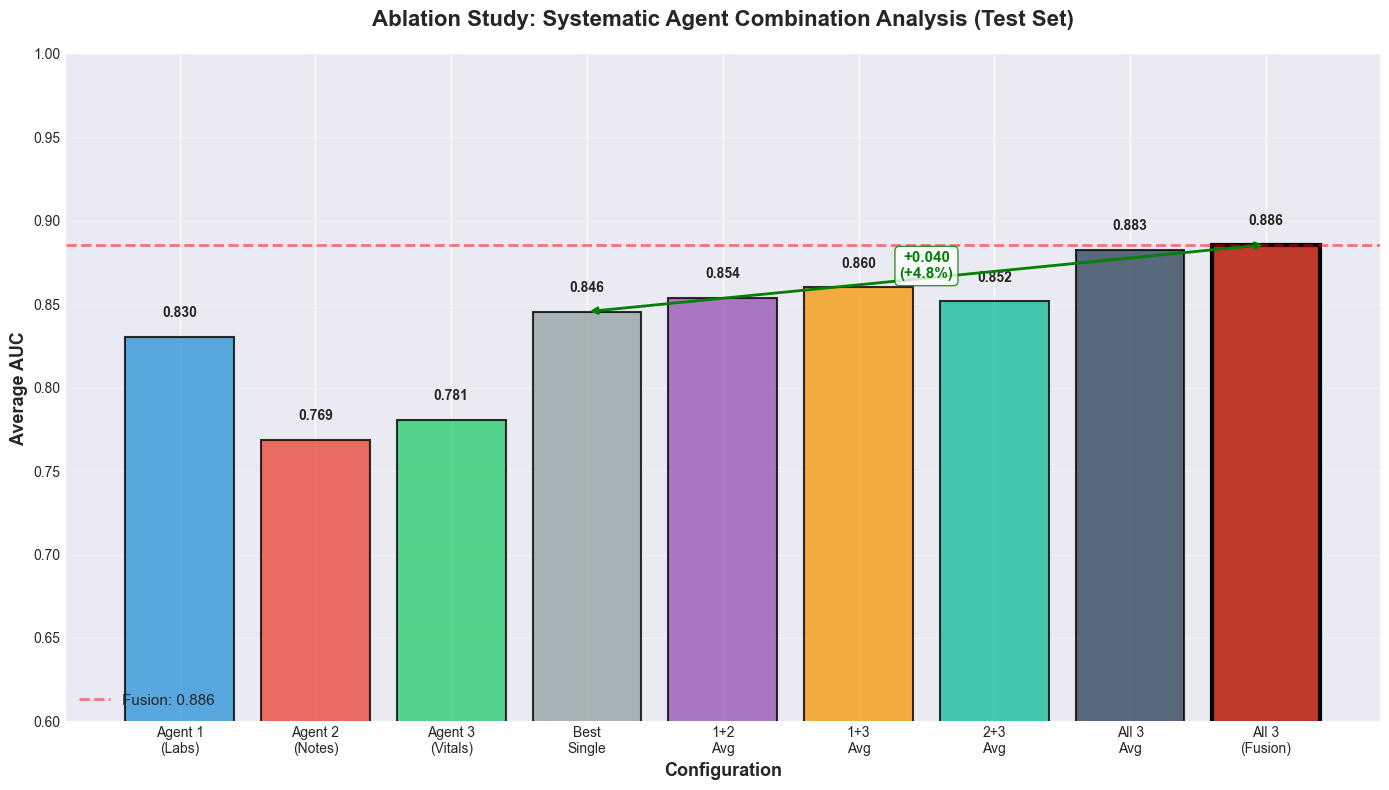

✅ Saved: ../results/ablation_study_test_set_cascade.png


In [32]:

print("\n📊 Creating Ablation Study Visualization...")

fig, ax = plt.subplots(figsize=(14, 8))

# Data for plotting
configs = [
    'Agent 1\n(Labs)',
    'Agent 2\n(Notes)',
    'Agent 3\n(Vitals)',
    'Best\nSingle',
    '1+2\nAvg',
    '1+3\nAvg',
    '2+3\nAvg',
    'All 3\nAvg',
    'All 3\n(Fusion)'
]

values = [
    ablation_df['Agent 1'].mean(),
    ablation_df['Agent 2'].mean(),
    ablation_df['Agent 3'].mean(),
    ablation_df['Best Single'].mean(),
    ablation_df['1+2 Avg'].mean(),
    ablation_df['1+3 Avg'].mean(),
    ablation_df['2+3 Avg'].mean(),
    ablation_df['All Avg'].mean(),
    ablation_df['Fusion'].mean()
]

# Color by type
colors = ['#3498db', '#e74c3c', '#2ecc71', '#95a5a6',
          '#9b59b6', '#f39c12', '#1abc9c', '#34495e', '#c0392b']

bars = ax.bar(configs, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Highlight fusion
bars[-1].set_alpha(1.0)
bars[-1].set_linewidth(3)

# Add value labels
for i, (config, value) in enumerate(zip(configs, values)):
    ax.text(i, value + 0.01, f'{value:.3f}', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# Formatting
ax.set_ylabel('Average AUC', fontsize=13, fontweight='bold')
ax.set_xlabel('Configuration', fontsize=13, fontweight='bold')
ax.set_title('Ablation Study: Systematic Agent Combination Analysis (Test Set)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_ylim([0.6, 1.0])
ax.grid(axis='y', alpha=0.3)

# Add dashed line at fusion level
ax.axhline(y=values[-1], color='red', linestyle='--', alpha=0.5, linewidth=2, 
           label=f'Fusion: {values[-1]:.3f}')

# Add improvement annotation
best_single_idx = 3
fusion_idx = 8
improvement = values[fusion_idx] - values[best_single_idx]

if improvement > 0:
    ax.annotate('', xy=(fusion_idx, values[fusion_idx]), 
                xytext=(best_single_idx, values[best_single_idx]),
                arrowprops=dict(arrowstyle='<->', color='green', lw=2))
    ax.text(5.5, (values[fusion_idx] + values[best_single_idx])/2, 
            f'+{improvement:.3f}\n({improvement/values[best_single_idx]*100:+.1f}%)',
            fontsize=11, fontweight='bold', color='green', ha='center',
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='green', alpha=0.8))

ax.legend(fontsize=11, loc='lower left')
plt.tight_layout()
plt.savefig('../../results/ablation_study_test_set_cascade.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Saved: ../results/ablation_study_test_set_cascade.png")

In [33]:

print("\n" + "="*70)
print("📈 STATISTICAL SIGNIFICANCE TESTING (TEST SET)")
print("="*70)

from scipy import stats

# Paired t-test: Fusion vs Best Single Agent
fusion_aucs = ablation_df['Fusion'].values
best_single_aucs = ablation_df['Best Single'].values

t_stat, p_value = stats.ttest_rel(fusion_aucs, best_single_aucs)

print(f"\nPaired t-test: Fusion vs Best Single Agent")
print(f"  t-statistic: {t_stat:.4f}")
print(f"  p-value:     {p_value:.6f}")
print(f"  Significant: {'YES ✅' if p_value < 0.05 else 'NO ❌'} (α=0.05)")

if p_value < 0.001:
    print(f"  → Highly significant (p < 0.001)")
elif p_value < 0.01:
    print(f"  → Very significant (p < 0.01)")
elif p_value < 0.05:
    print(f"  → Significant (p < 0.05)")
else:
    print(f"  → Not significant (p ≥ 0.05)")

# Effect size (Cohen's d)
mean_diff = fusion_aucs.mean() - best_single_aucs.mean()
pooled_std = np.sqrt((fusion_aucs.std()**2 + best_single_aucs.std()**2) / 2)
cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0

print(f"\nEffect size (Cohen's d): {cohens_d:.3f}")
if abs(cohens_d) < 0.2:
    print("  → Small effect")
elif abs(cohens_d) < 0.5:
    print("  → Medium effect")
else:
    print(f"  → Large effect {'✅' if cohens_d > 0 else '⚠️'}")

# Wilcoxon signed-rank test
w_stat, w_pvalue = stats.wilcoxon(fusion_aucs, best_single_aucs)
print(f"\nWilcoxon signed-rank test (non-parametric):")
print(f"  W-statistic: {w_stat:.4f}")
print(f"  p-value:     {w_pvalue:.6f}")
print(f"  Significant: {'YES ✅' if w_pvalue < 0.05 else 'NO ❌'}")

# Win-Loss record
wins = (fusion_aucs > best_single_aucs).sum()
losses = (fusion_aucs < best_single_aucs).sum()
ties = (fusion_aucs == best_single_aucs).sum()

print(f"\nWin-Loss Record:")
print(f"  Fusion wins:  {wins}/{len(DISEASE_LIST)} diseases ({wins/len(DISEASE_LIST)*100:.1f}%)")
print(f"  Fusion loses: {losses}/{len(DISEASE_LIST)} diseases ({losses/len(DISEASE_LIST)*100:.1f}%)")
print(f"  Ties:         {ties}/{len(DISEASE_LIST)} diseases ({ties/len(DISEASE_LIST)*100:.1f}%)")


📈 STATISTICAL SIGNIFICANCE TESTING (TEST SET)

Paired t-test: Fusion vs Best Single Agent
  t-statistic: 7.7993
  p-value:     0.000052
  Significant: YES ✅ (α=0.05)
  → Highly significant (p < 0.001)

Effect size (Cohen's d): 1.017
  → Large effect ✅

Wilcoxon signed-rank test (non-parametric):
  W-statistic: 0.0000
  p-value:     0.003906
  Significant: YES ✅

Win-Loss Record:
  Fusion wins:  9/9 diseases (100.0%)
  Fusion loses: 0/9 diseases (0.0%)
  Ties:         0/9 diseases (0.0%)
